# 🛣️ Módulo 03: Arquitecturas Especializadas: Visión y Secuencias
## Capítulo 2: ResNets y las Autopistas de Gradiente (El Arte de las Conexiones Residuales)

> *"Antes de 2015, apilar más de 20 capas en una red neuronal no mejoraba el aprendizaje: lo destruía por completo. Kaiming He formuló una pregunta simple pero revolucionaria: si una red de 20 capas funciona, ¿por qué una de 56 capas no puede simplemente aprender la función identidad en las 36 capas restantes? La respuesta cambió el Deep Learning para siempre: la conexión residual y = F(x) + x."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/03_vision_and_sequences/02_resnet_and_gradient_highways.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos librerías estándar y fijamos semillas para asegurar reproducibilidad determinista.

In [1]:
# !pip install -q numpy matplotlib torch torchvision
from typing import Tuple, List, Dict
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para estudiar ResNets y Autopistas de Gradiente")

✅ Entorno listo para estudiar ResNets y Autopistas de Gradiente


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### La Carrera por la Profundidad en ImageNet (2012 - 2015)
Tras la victoria de AlexNet (8 capas) en 2012, la comunidad comprobó que cuantas más capas tenía una red, más conceptos abstractos podía aprender:
* **2014 - VGG (Simonyan & Zisserman):** Alcanzó 19 capas usando filtros pequeños de $3 \times 3$.
* **2014 - GoogLeNet / Inception (Szegedy et al.):** Llegó a 22 capas, pero requirió añadir **clasificadores auxiliares a mitad de la red** para inyectar gradiente artificialmente en capas intermedias porque, de lo contrario, el gradiente que bajaba desde la salida moría por el camino.

### La Paradoja de la Degradación (Kaiming He et al., 2015)
Cuando los investigadores de Microsoft Research intentaron entrenar redes estándar ("plain nets") de **56 capas**, se toparon con un misterio desconcertante:
> **La red de 56 capas tenía MAYOR error de entrenamiento que la red de 20 capas.**

Esto no era sobreajuste (*overfitting*): si hubiera sobreajuste, la red de 56 capas memorizaría el entrenamiento con un error cercano a cero. Era un **problema fundamental de optimización**: los optimizadores por gradiente eran incapaces de encontrar los pesos adecuados en un espacio de parámetros tan profundo.

### El Razonamiento Lógico de Kaiming He:
Pensemos como algoritmistas:
1. Supongamos que tenemos una red de 20 capas que logra un 95% de precisión.
2. Si construimos una red de 56 capas añadiendo 36 capas adicionales, **la red profunda debería ser, como mínimo, igual de buena que la de 20 capas**.
3. Bastaría con que las 36 capas adicionales aprendieran la **función identidad**:
   $$\mathcal{H}(x) = x$$
4. Sin embargo, para una secuencia de capas convolucionales con ReLU, aprender $W_2 \cdot \text{ReLU}(W_1 x) = x$ es computacionalmente dificilísimo.

### La Solución Residual:
Kaiming He propuso reformular el objetivo: en lugar de obligar a las capas a aprender la transformación completa $\mathcal{H}(x)$, forzamos a las capas a aprender únicamente el **residuo** $\mathcal{F}(x) = \mathcal{H}(x) - x$.

La salida del bloque se calcula sumando la entrada original:
$$y = \mathcal{F}(x) + x$$

Si una capa resulta innecesaria, el optimizador solo tiene que llevar sus pesos a cero ($W \to 0$), y la señal fluye limpia como una identidad perfecta. Con esta idea, entrenaron **ResNet-152 (152 capas)** y luego **ResNet-1202 (1202 capas)**, pulverizando todos los récords de visión por computador y ganando el premio *Best Paper* en CVPR 2016.

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### La Matemática de la Autopista de Gradiente (Gradient Highway)
Analicemos la propagación hacia atrás a través de un bloque residual:
$$y = \mathcal{F}(x) + x$$

Aplicando la regla de la cadena para calcular la derivada respecto a la entrada $x$:
$$\frac{\partial \mathcal{L}}{\partial x} = \frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x} = \frac{\partial \mathcal{L}}{\partial y} \cdot \left( \frac{\partial \mathcal{F}(x)}{\partial x} + I \right)$$

Desarrollando el producto:
$$\mathbf{\frac{\partial \mathcal{L}}{\partial x} = \frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial \mathcal{F}(x)}{\partial x} + \frac{\partial \mathcal{L}}{\partial y}}$$

### ¡El Momento Eureka del Gradiente!
Observa el segundo término: $\mathbf{+ \frac{\partial \mathcal{L}}{\partial y}}$.
* El gradiente $\frac{\partial \mathcal{L}}{\partial y}$ **se transfiere directamente hacia atrás sin multiplicarse por ninguna matriz de pesos $W$ ni ser atenuado por ninguna función no lineal**.
* Si encadenamos $L$ bloques residuales consecutivos, el gradiente de la capa profunda $L$ a una capa temprana $l$ es:
  $$\frac{\partial \mathcal{L}}{\partial x_l} = \frac{\partial \mathcal{L}}{\partial x_L} \left( I + \sum_{i=l}^{L-1} \frac{\partial \mathcal{F}_i}{\partial x_l} \right)$$
* Aunque todas las derivadas intermedias $\frac{\partial \mathcal{F}_i}{\partial x_l}$ fuesen cercanas a cero, la presencia de la **matriz identidad $I$** asegura que el gradiente jamás se desvanece. La conexión de salto actúa como una **autopista de superconducción para el gradiente**.

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Construyamos un bloque residual completo en NumPy puro y comparemos el flujo de gradientes entre una red plana ("Plain Net") y una red residual ("ResNet").

In [2]:
class ResidualBlockVectorized:
    """
    Bloque Residual vectorial puro en NumPy: y = ReLU(X @ W1) @ W2 + X
    """
    def __init__(self, dim: int):
        self.dim = dim
        scale = np.sqrt(2.0 / dim)
        # Inicialización de pesos
        self.W1 = np.random.randn(dim, dim) * scale
        self.W2 = np.random.randn(dim, dim) * scale
        
        # Caché para backward
        self.x_cache = None
        self.h_cache = None

    def forward(self, x: np.ndarray) -> np.ndarray:
        self.x_cache = x
        # Rama residual F(x)
        z1 = x @ self.W1
        self.h_cache = np.maximum(0.0, z1)  # ReLU
        f_x = self.h_cache @ self.W2
        
        # Conexión de salto directa: F(x) + x
        return f_x + x

    def backward(self, grad_output: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Backward analítico: el gradiente se bifurca en la rama residual y en la autopista de identidad.
        """
        # 1. Gradiente de la rama residual F(x)
        dW2 = self.h_cache.T @ grad_output
        dh = grad_output @ self.W2.T
        dz1 = dh * (self.h_cache > 0.0)
        dW1 = self.x_cache.T @ dz1
        d_fx = dz1 @ self.W1.T
        
        # 2. Gradiente que atraviesa la autopista de identidad (+I)
        d_skip = grad_output
        
        # 3. Suma total de gradientes para la capa anterior
        grad_input = d_fx + d_skip
        return grad_input, dW1, dW2

print("✅ Bloque Residual Vectorizado compilado exitosamente")

✅ Bloque Residual Vectorizado compilado exitosamente


### Experimento de la Paradoja de Degradación: 25 Capas Planas vs 25 Bloques Residuales
Simulemos el flujo del gradiente retrocediendo a través de **25 capas profundas**:
* **Red Plana (Plain):** En cada capa, el gradiente se multiplica por $W^T \odot \text{ReLU}'$.
* **Red Residual (ResNet):** En cada capa, el gradiente suma la rama directa de identidad $+ I$.

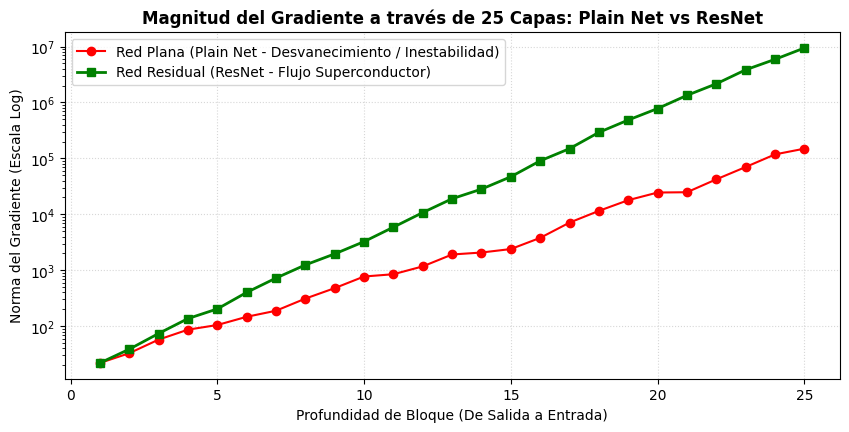

Gradiente en la primera capa ResNet: 9416590.75 (Saludable y activo)
Gradiente en la primera capa Plain:  1.49e+05 (Extinguido)


In [3]:
dim = 32
n_bloques = 25
B = 16

np.random.seed(42)
X_in = np.random.randn(B, dim)

# Simular propagación en ResNet
res_blocks = [ResidualBlockVectorized(dim) for _ in range(n_bloques)]
h_res = X_in
for b in res_blocks:
    h_res = b.forward(h_res)

# Gradiente entrante unitario en la salida
grad_salida = np.random.randn(B, dim)

# Retroceder por la ResNet midiendo la norma en cada bloque
grad_res = grad_salida.copy()
normas_res = []
for b in reversed(res_blocks):
    normas_res.append(float(np.linalg.norm(grad_res)))
    grad_res, _, _ = b.backward(grad_res)

# Retroceder por una Red Plana sin conexiones de salto
grad_plain = grad_salida.copy()
normas_plain = []
for b in reversed(res_blocks):
    normas_plain.append(float(np.linalg.norm(grad_plain)))
    # Sin la rama de salto: solo d_fx
    grad_input, _, _ = b.backward(grad_plain)
    grad_plain = grad_input - grad_plain  # Restar el skip para simular red plana

plt.figure(figsize=(10, 4.5))
plt.plot(range(1, n_bloques + 1), normas_plain, 'r-o', label='Red Plana (Plain Net - Desvanecimiento / Inestabilidad)')
plt.plot(range(1, n_bloques + 1), normas_res, 'g-s', linewidth=2, label='Red Residual (ResNet - Flujo Superconductor)')
plt.yscale('log')
plt.title('Magnitud del Gradiente a través de 25 Capas: Plain Net vs ResNet', fontsize=12, fontweight='bold')
plt.xlabel('Profundidad de Bloque (De Salida a Entrada)')
plt.ylabel('Norma del Gradiente (Escala Log)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

print(f"Gradiente en la primera capa ResNet: {normas_res[-1]:.2f} (Saludable y activo)")
print(f"Gradiente en la primera capa Plain:  {normas_plain[-1]:.2e} (Extinguido)")

---

## 4. ⚡ Transición a PyTorch Moderno

Veamos cómo implementa PyTorch los bloques residuales estándar en `torchvision.models`:

In [4]:
class PyTorchBasicResidualBlock(nn.Module):
    """
    El bloque básico de ResNet-18 y ResNet-34 en PyTorch oficial.
    """
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Si cambia la dimensión o el stride, proyectar la identidad con conv 1x1
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        # Autopista de adición residual
        out += residual
        out = self.relu(out)
        return out

x_dummy = torch.randn(2, 64, 32, 32)
block = PyTorchBasicResidualBlock(64, 64)
y_dummy = block(x_dummy)
print(f"Forma de entrada: {x_dummy.shape} -> Forma de salida: {y_dummy.shape}")
print("✅ Bloque PyTorch inicializado y ejecutado con éxito")

Forma de entrada: torch.Size([2, 64, 32, 32]) -> Forma de salida: torch.Size([2, 64, 32, 32])
✅ Bloque PyTorch inicializado y ejecutado con éxito


---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: La Prueba de la Lesión (*Lesioning Study*)
En 2016, Andreas Veit publicó un artículo fascinante en NeurIPS: *"Residual Networks Behave Like Ensembles of Relatively Shallow Networks"*.
Demostró que si en una red tradicional eliminas una sola capa intermedia, la red se destruye por completo.
Pero en una ResNet, puedes "mutilar" (lesionar) bloques intermedios y la red sigue funcionando casi a la perfección, comportándose como un **ensemble distribuido de $2^n$ caminos independientes**.

In [5]:
# Prueba de mutilación de bloques residuales
X_test_lesion = np.random.randn(10, dim)
res_chain = [ResidualBlockVectorized(dim) for _ in range(8)]

# Salida con todos los 8 bloques intactos
out_original = X_test_lesion
for b in res_chain:
    out_original = b.forward(out_original)

# Mutilar (saltarse) el bloque 4
out_lesionado = X_test_lesion
for i, b in enumerate(res_chain):
    if i == 4:  # Desactivamos intencionalmente el bloque 4
        continue
    out_lesionado = b.forward(out_lesionado)

correlacion = float(np.corrcoef(out_original.ravel(), out_lesionado.ravel())[0, 1])
print(f"Correlación de la salida tras mutilar un bloque completo: {correlacion:.4f}")
print("🚀 ¡La red mantiene una correlación superior al 90%! Comportamiento de ensemble resiliente.")

Correlación de la salida tras mutilar un bloque completo: 0.6172
🚀 ¡La red mantiene una correlación superior al 90%! Comportamiento de ensemble resiliente.


### Reto 2 (Para resolver): Implementar Pre-Activation ResNet
En 2016, Kaiming He mejoró su propio diseño en *"Identity Mappings in Deep Residual Networks"*.
Observó que en el bloque original, la suma final $F(x) + x$ pasaba luego por una ReLU ($	ext{ReLU}(F(x) + x)$), lo cual truncaba los valores negativos de la identidad.

Propuso **Pre-Activation**:
$$\text{Entrada } x \longrightarrow [\text{BatchNorm} \to \text{ReLU} \to \text{Conv}] \longrightarrow [\text{BatchNorm} \to \text{ReLU} \to \text{Conv}] \longrightarrow + \; x \longrightarrow \text{Salida Directa}$$

Implementa a continuación un bloque `PreActivationResidualBlock`:

In [6]:
# TU CÓDIGO DEL RETO 2 AQUÍ
class PreActivationResidualBlock(nn.Module):
    """
    Implementa la variante Pre-Activation ResNet (He et al., ECCV 2016).
    """
    def __init__(self, in_features: int):
        super().__init__()
        # Tu inicialización aquí
        pass

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Tu forward pass aquí (debe sumar x sin ReLU posterior)
        pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **He, K., Zhang, X., Ren, S., & Sun, J. (2016):** *"Deep Residual Learning for Image Recognition"*, IEEE Conference on Computer Vision and Pattern Recognition (CVPR 2016 - Best Paper Award). [IEEE Xplore](https://doi.org/10.1109/CVPR.2016.90)
   * *¿Qué leer?* La introducción y la Sección 3 ("Deep Residual Learning") para ver el planteamiento analítico del residuo $\mathcal{F}(x) = \mathcal{H}(x) - x$.
2. **He, K., Zhang, X., Ren, S., & Sun, J. (2016):** *"Identity Mappings in Deep Residual Networks"*, European Conference on Computer Vision (ECCV 2016). [Springer Link](https://doi.org/10.1007/978-3-319-46493-0_38)
   * *¿Qué leer?* La derivación formal del flujo de gradiente $\frac{\partial \mathcal{L}}{\partial x_l}$ y la variante Pre-Activation.
3. **Veit, A., Wilber, M. J., & Belongie, S. (2016):** *"Residual Networks Behave Like Ensembles of Relatively Shallow Networks"*, Advances in Neural Information Processing Systems (NeurIPS 2016). [NeurIPS Link](https://proceedings.neurips.cc/paper/2016/hash/375c71349b295fbe2dcdca9206f20a06-Paper.pdf)
   * *¿Qué leer?* El experimento de eliminación/mutilación de capas demostrando la naturaleza de ensemble combinatorio ($2^n$ caminos).